In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (mean_absolute_error,mean_squared_error)

df = pd.read_csv("../data/processed/processed_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df_clean = df.dropna().copy()
print(f"Data shape: {df_clean.shape}")
df_clean.head()


Data shape: (261083, 32)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
52,1,1,2011-02-04,21665.76,0,2011,2,5,42.27,2.989,...,17341.47,15984.24,31497.65,24924.50,17286.6475,1013.925386,25087.749167,12701.860945,19720.954335,23775.964205
53,1,1,2011-02-11,37887.17,1,2011,2,6,36.39,3.022,...,18461.18,17359.70,44912.86,46039.49,18707.0275,2040.798674,25264.113333,12632.473744,20498.876601,23451.317404
54,1,1,2011-02-18,46845.87,0,2011,2,7,57.36,3.045,...,21665.76,17341.47,55931.23,41595.55,23838.8950,9543.110891,26791.974167,12982.799578,27454.193961,25672.217804
55,1,1,2011-02-25,19363.83,0,2011,2,8,62.90,3.065,...,37887.17,18461.18,19124.58,19403.54,31214.9950,13449.781394,29127.439167,13906.316950,35210.864376,28929.702757
56,1,1,2011-03-04,20327.61,0,2011,3,9,59.58,3.288,...,46845.87,21665.76,15984.24,21827.90,31440.6575,13169.111324,28864.628333,14071.411666,28872.050626,27458.030025


In [2]:
df_clean = df_clean.sort_values(["Store", "Dept", "Date"])
df_clean.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
52,1,1,2011-02-04,21665.76,0,2011,2,5,42.27,2.989,...,17341.47,15984.24,31497.65,24924.50,17286.6475,1013.925386,25087.749167,12701.860945,19720.954335,23775.964205
53,1,1,2011-02-11,37887.17,1,2011,2,6,36.39,3.022,...,18461.18,17359.70,44912.86,46039.49,18707.0275,2040.798674,25264.113333,12632.473744,20498.876601,23451.317404
54,1,1,2011-02-18,46845.87,0,2011,2,7,57.36,3.045,...,21665.76,17341.47,55931.23,41595.55,23838.8950,9543.110891,26791.974167,12982.799578,27454.193961,25672.217804
55,1,1,2011-02-25,19363.83,0,2011,2,8,62.90,3.065,...,37887.17,18461.18,19124.58,19403.54,31214.9950,13449.781394,29127.439167,13906.316950,35210.864376,28929.702757
56,1,1,2011-03-04,20327.61,0,2011,3,9,59.58,3.288,...,46845.87,21665.76,15984.24,21827.90,31440.6575,13169.111324,28864.628333,14071.411666,28872.050626,27458.030025


In [3]:
df_clean.groupby(["Store","Dept"]).ngroups

2989

In [4]:
store = 1
dept = 1

series = df_clean[(df_clean["Store"] == store) &(df_clean["Dept"] == dept)].copy()

series = series[["Date","Weekly_Sales"]]

series.set_index("Date",inplace=True)

series.head()

,Weekly_Sales
Date,
2011-02-04,21665.76
2011-02-11,37887.17
2011-02-18,46845.87
2011-02-25,19363.83
2011-03-04,20327.61


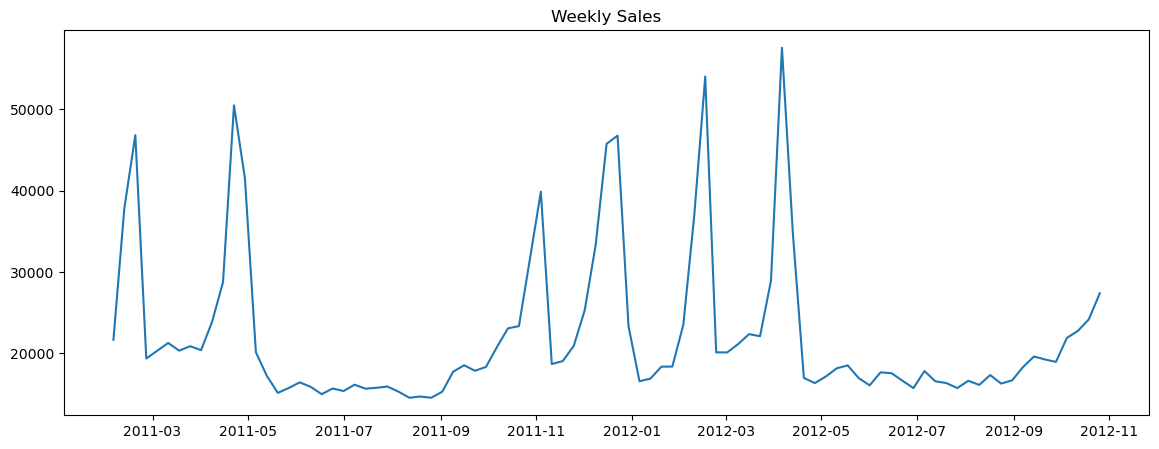

In [5]:
plt.figure(figsize=(14,5))

plt.plot(series)

plt.title("Weekly Sales")

plt.show()

In [6]:
split_date = "2012-03-01"

train = series.loc[:split_date]

valid = series.loc[split_date:]
print(train.shape)
print(valid.shape)


(56, 1)
(35, 1)


In [7]:
# ARIMA is a time series model. It doesn't just use the order of observations—it also expects to know how often observations occur.
series = series.asfreq("W-FRI")

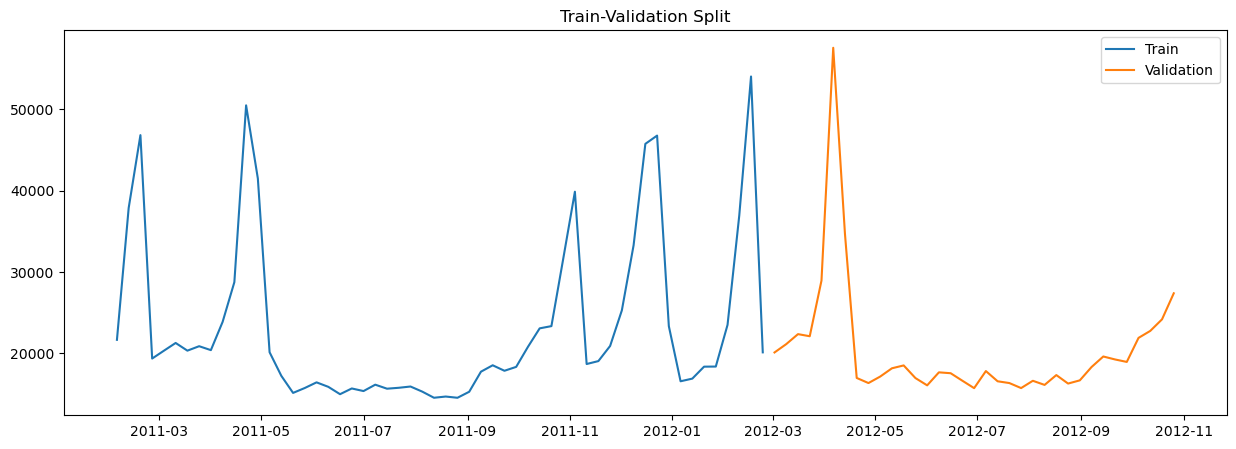

In [8]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Train")
plt.plot(valid, label="Validation")

plt.legend()

plt.title("Train-Validation Split")

plt.show()

In [9]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(train["Weekly_Sales"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1]<0.05:
    print("Series is stationary")
else:
    print("Series isn't stationary")

ADF Statistic : -4.765442440367067
p-value : 6.329805983306953e-05
Series is stationary


In [10]:
from statsmodels.tsa.stattools import kpss

result = kpss(train["Weekly_Sales"])

print("KPSS Statistic :", result[0])
print("p-value :", result[1])

if result[1]>0.05:
    print("Series is stationary")
else:
    print("Series isn't stationary")

KPSS Statistic : 0.21360067841445465
p-value : 0.1
Series is stationary


C:\Users\Swaraj Shedge\AppData\Local\Temp\ipykernel_16012\4270702191.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(train["Weekly_Sales"])


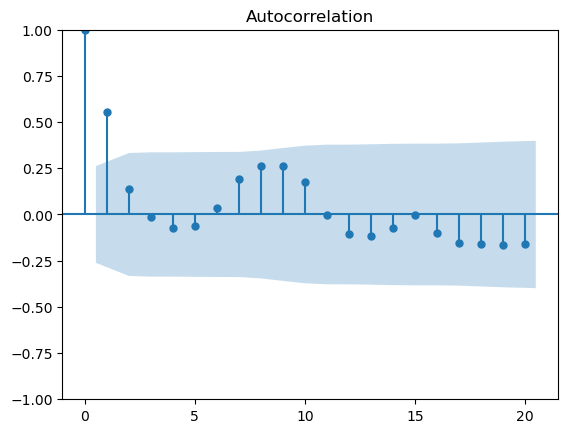

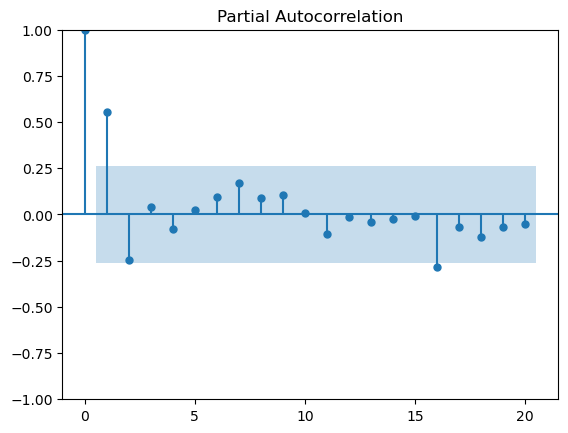

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(train["Weekly_Sales"], lags=20)
plt.show()

plot_pacf(train["Weekly_Sales"], lags=20)
plt.show()

In [ ]:
model = ARIMA(train["Weekly_Sales"],order=(2,1,1))

model_fit = model.fit()

c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\Swaraj Shedge\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [13]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                   56
Model:                 ARIMA(2, 1, 1)   Log Likelihood                -574.698
Date:                Fri, 26 Jun 2026   AIC                           1157.397
Time:                        12:44:57   BIC                           1165.426
Sample:                    02-04-2011   HQIC                          1160.502
                         - 02-24-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7628      0.160      4.759      0.000       0.449       1.077
ar.L2         -0.4307      0.146     -2.954      0.003      -0.717      -0.145
ma.L1         -0.9049      0.130     -6.964      0.0

In [ ]:
forecast = model_fit.forecast(steps=len(valid))

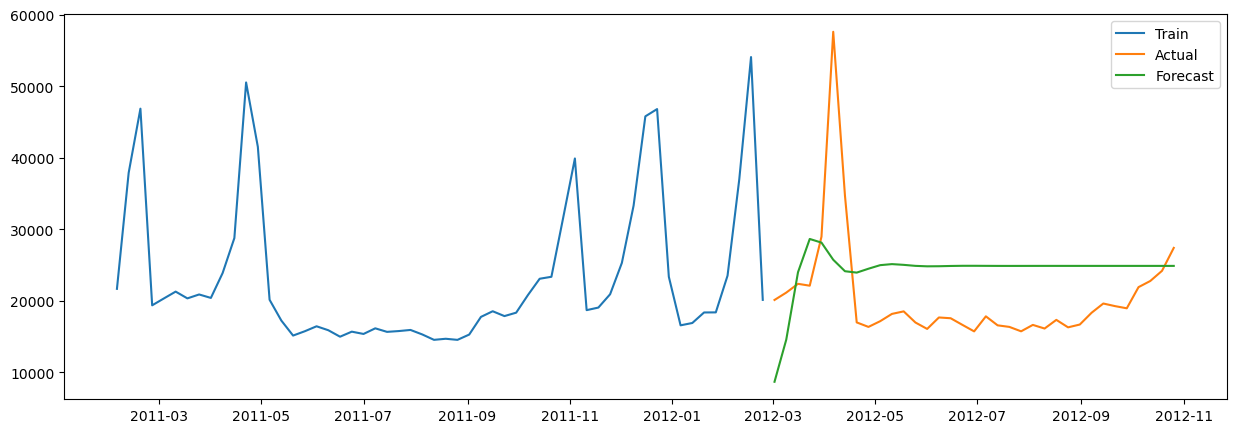

In [15]:
plt.figure(figsize=(15,5))

plt.plot(train, label="Train")
plt.plot(valid, label="Actual")
plt.plot(valid.index, forecast, label="Forecast")

plt.legend()

plt.show()

In [16]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(valid["Weekly_Sales"],forecast)

print("MAE :", mae)

MAE : 7437.777814919958


In [17]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(valid["Weekly_Sales"],forecast))

print("RMSE :", rmse)

RMSE : 8917.907947494083


In [18]:
mape = np.mean(np.abs((valid["Weekly_Sales"] - forecast) /valid["Weekly_Sales"])) * 100

print("MAPE :", mape)
print("Accuracy:",100-mape)

MAPE : 37.756354736121196
Accuracy: 62.243645263878804


In [19]:
wmape = (np.abs(valid["Weekly_Sales"] - forecast).sum()/np.abs(valid["Weekly_Sales"]).sum()) * 100

print("wMAPE :", wmape)

wMAPE : 36.326548703449475


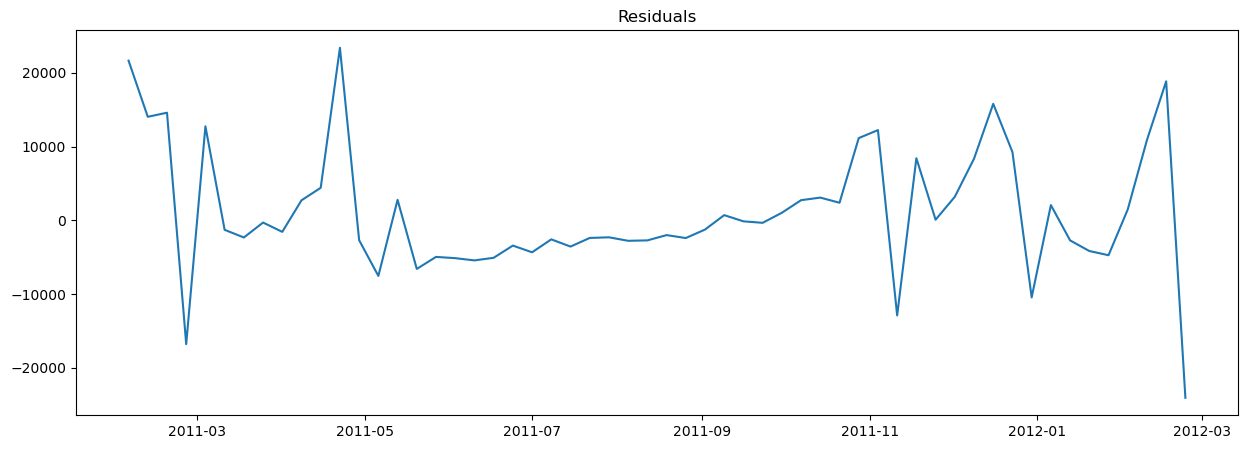

In [20]:
residuals = model_fit.resid

plt.figure(figsize=(15,5))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

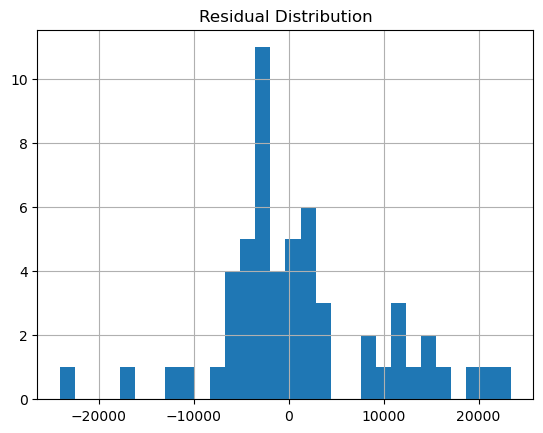

In [21]:
residuals.hist(bins=30)
plt.title("Residual Distribution")
plt.show()

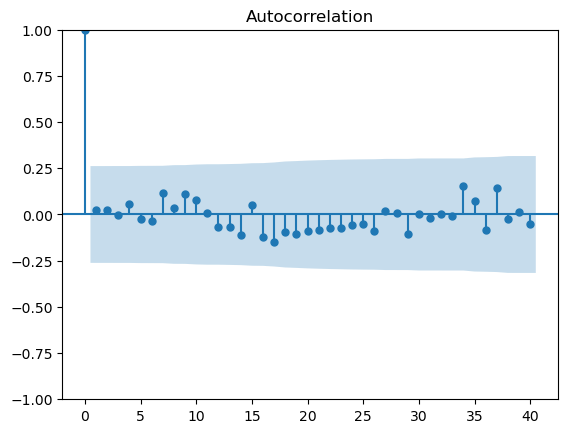

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=40)
plt.show()

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung = acorr_ljungbox(residuals,lags=[10],return_df=True)

print(ljung)

     lb_stat  lb_pvalue
10  2.582857   0.989612


# ARIMA USING statsforecast

In [ ]:
# pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [25]:
import pandas as pd
import numpy as np

from statsforecast import StatsForecast
from statsforecast.models import AutoARIMA

In [26]:
df_new= df.dropna().copy()


In [27]:
df_new.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Year,Month,Week,Temperature,Fuel_Price,...,Lag_2,Lag_4,Lag_8,Lag_52,Sales_Roll_Mean_4,Sales_Roll_Std_4,Sales_Roll_Mean_12,Sales_Roll_Std_12,Sales_EMA_4,Sales_EMA_12
52,1,1,2011-02-04,21665.76,0,2011,2,5,42.27,2.989,...,17341.47,15984.24,31497.65,24924.50,17286.6475,1013.925386,25087.749167,12701.860945,19720.954335,23775.964205
53,1,1,2011-02-11,37887.17,1,2011,2,6,36.39,3.022,...,18461.18,17359.70,44912.86,46039.49,18707.0275,2040.798674,25264.113333,12632.473744,20498.876601,23451.317404
54,1,1,2011-02-18,46845.87,0,2011,2,7,57.36,3.045,...,21665.76,17341.47,55931.23,41595.55,23838.8950,9543.110891,26791.974167,12982.799578,27454.193961,25672.217804
55,1,1,2011-02-25,19363.83,0,2011,2,8,62.90,3.065,...,37887.17,18461.18,19124.58,19403.54,31214.9950,13449.781394,29127.439167,13906.316950,35210.864376,28929.702757
56,1,1,2011-03-04,20327.61,0,2011,3,9,59.58,3.288,...,46845.87,21665.76,15984.24,21827.90,31440.6575,13169.111324,28864.628333,14071.411666,28872.050626,27458.030025


In [28]:
df_new.shape

(261083, 32)

In [29]:
df_new = df_new.rename(columns={"Store":"store","Dept":"dept","Date":"ds","Weekly_Sales":"y"})

In [30]:
df_new["unique_id"] = (df_new["store"].astype(str)+ "_"+ df_new["dept"].astype(str))


In [31]:
df_new = df_new[["unique_id","ds","y"]]

In [32]:
split_date = "2012-03-01"

train = df_new[df_new.ds <= split_date]

valid = df_new[df_new.ds > split_date]

In [33]:
sf = StatsForecast(models=[AutoARIMA()],freq="W-FRI",n_jobs=-1)

In [34]:
sf.fit(train)

StatsForecast(models=[AutoARIMA])

In [35]:
h = valid["ds"].nunique()

In [36]:
forecast = sf.predict(h=h)

In [37]:
results = valid.merge(forecast,on=["unique_id","ds"])
print(results)

       unique_id         ds         y     AutoARIMA
0            1_1 2012-03-02  20113.03   6979.454825
1            1_1 2012-03-09  21140.07  23084.869233
2            1_1 2012-03-16  22366.88  23084.869233
3            1_1 2012-03-23  22107.70  23084.869233
4            1_1 2012-03-30  28952.86  23084.869233
...          ...        ...       ...           ...
100735     45_98 2012-09-28    508.37    750.502580
100736     45_98 2012-10-05    628.10    750.502580
100737     45_98 2012-10-12   1061.02    750.502580
100738     45_98 2012-10-19    760.01    750.502580
100739     45_98 2012-10-26   1076.80    750.502580

[100740 rows x 4 columns]


In [ ]:
mae = np.mean(np.abs(results["y"] -results["AutoARIMA"]))
print(mae)

2713.7719888779257


In [39]:
rmse = np.sqrt(np.mean((results["y"]-results["AutoARIMA"])**2))
print(rmse)

5992.584875339259


In [40]:
wmape = (np.abs(results["y"]-results["AutoARIMA"]).sum()/np.abs(results["y"]).sum())*100
print(wmape)
print("Accuracy:",100-wmape)

16.68454025700337
Accuracy: 83.31545974299664
